# Does the day of max temperature in summer correlate with the Onset date of summer?
### Hypo: yes, because an earlier summer leads to earlier drying of soils (and impacts cloud formation?) and hence over land sensible heating is higher, earlier. 

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# for correlations
import xskillscore as xs

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [2]:
# read in summer metrics which includes onset date and day of max temp
ds = xr.open_dataset('../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc')
ds

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

#### Pearson correlation and map

In [13]:
%%time

# pearson correlation
# day of summer onset
onset = ds.SummerStart

# day of max temp in summer
tmax = ds.SummerTmax

p_corr = xs.pearson_r(onset, tmax, dim='time')
p_corr_p = xs.pearson_r_p_value(onset, tmax, dim='time')

CPU times: user 682 ms, sys: 655 ms, total: 1.34 s
Wall time: 1.35 s


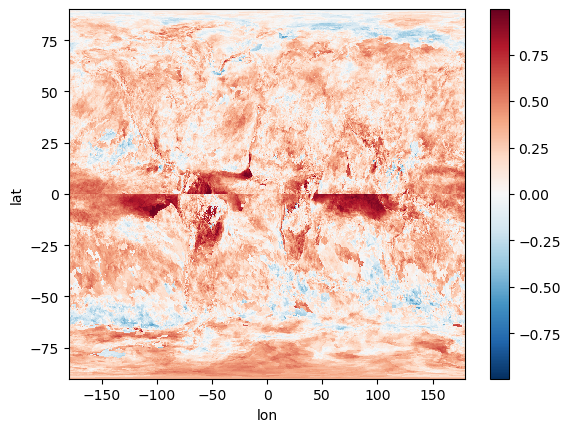

In [14]:
p_corr.plot()

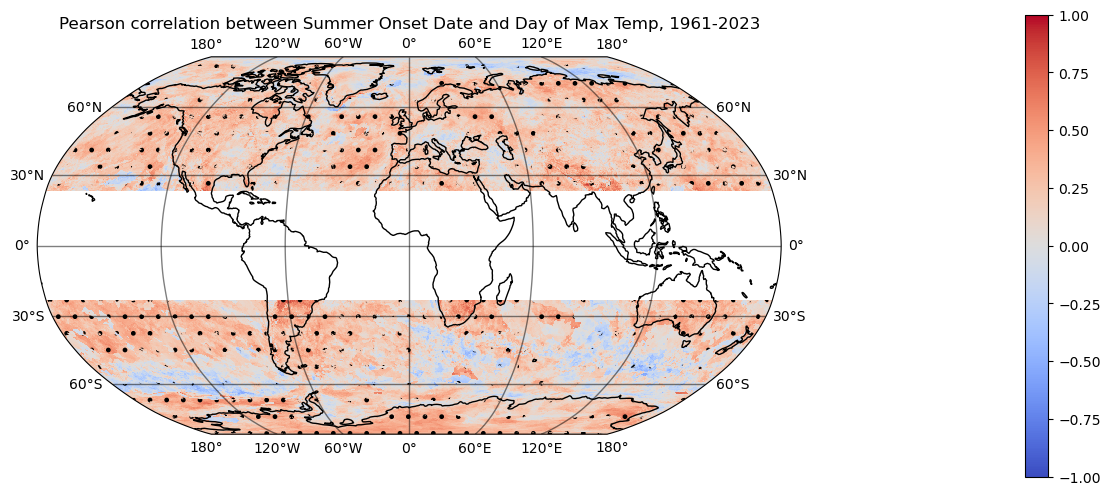

In [15]:
%%time

# Global summer length trend
fig = plt.figure(figsize=(15,12))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True,linewidth=1, color='black', alpha=0.5)

p_corr.where((p_corr.lat >= 23.5) | (p_corr.lat <= -23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-1,
    vmax=1, 
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)

# mask for sig at p < 0.05 
mksig = p_corr_p.where((p_corr.lat >= 23.5) | (p_corr.lat <= -23.5)) < 0.05

mksig.where(mksig.values).plot.contourf(hatches=".", transform=ccrs.PlateCarree(), 
                                        #colors='none', 
                                        cmap='none' )#cbar_kwargs={'shrink': 0.0})

# remove the colorbar from the contour
fig.axes[-1].remove()

plt.title("Pearson correlation between Summer Onset Date and Day of Max Temp, 1961-2023")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

#### Spearman correlation and map

In [16]:
%%time

# same but spearman

s_corr = xs.spearman_r(onset, tmax, dim='time')
s_corr_p = xs.spearman_r_p_value(onset, tmax, dim='time')

CPU times: user 6.46 s, sys: 1.67 s, total: 8.13 s
Wall time: 8.63 s


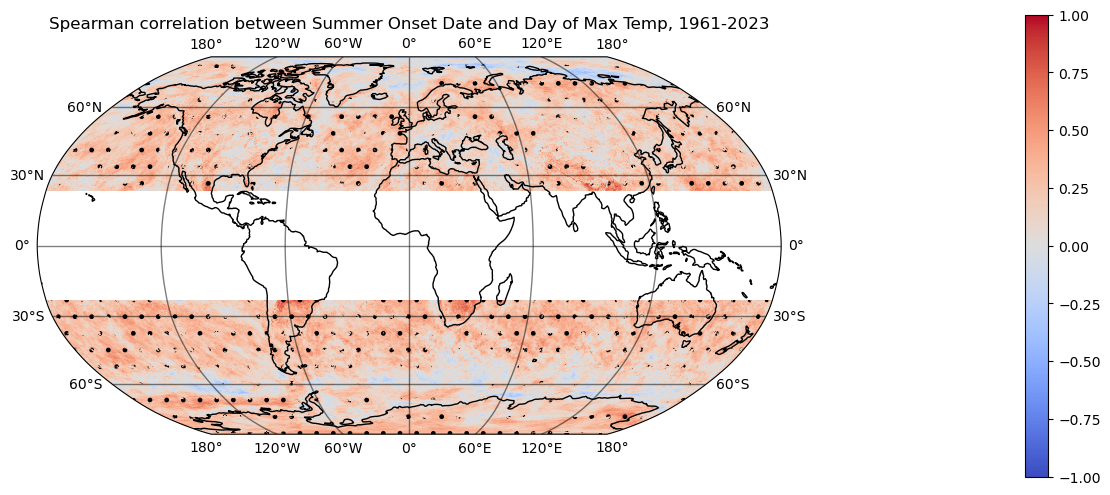

CPU times: user 30.8 s, sys: 539 ms, total: 31.3 s
Wall time: 31.5 s


In [18]:
%%time

# Global summer length trend
fig = plt.figure(figsize=(15,12))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True,linewidth=1, color='black', alpha=0.5)

s_corr.where((s_corr.lat >= 23.5) | (s_corr.lat <= -23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-1,
    vmax=1, 
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)

# mask for sig at p < 0.05 
mksig = s_corr_p.where((s_corr.lat >= 23.5) | (s_corr.lat <= -23.5)) < 0.05

mksig.where(mksig.values).plot.contourf(hatches=".", transform=ccrs.PlateCarree(), 
                                        #colors='none', 
                                        cmap='none' )#cbar_kwargs={'shrink': 0.0})

# remove the colorbar from the contour
fig.axes[-1].remove()

plt.title("Spearman correlation between Summer Onset Date and Day of Max Temp, 1961-2023")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

#### North America, Spearman - is there a strong correlation in the SW?

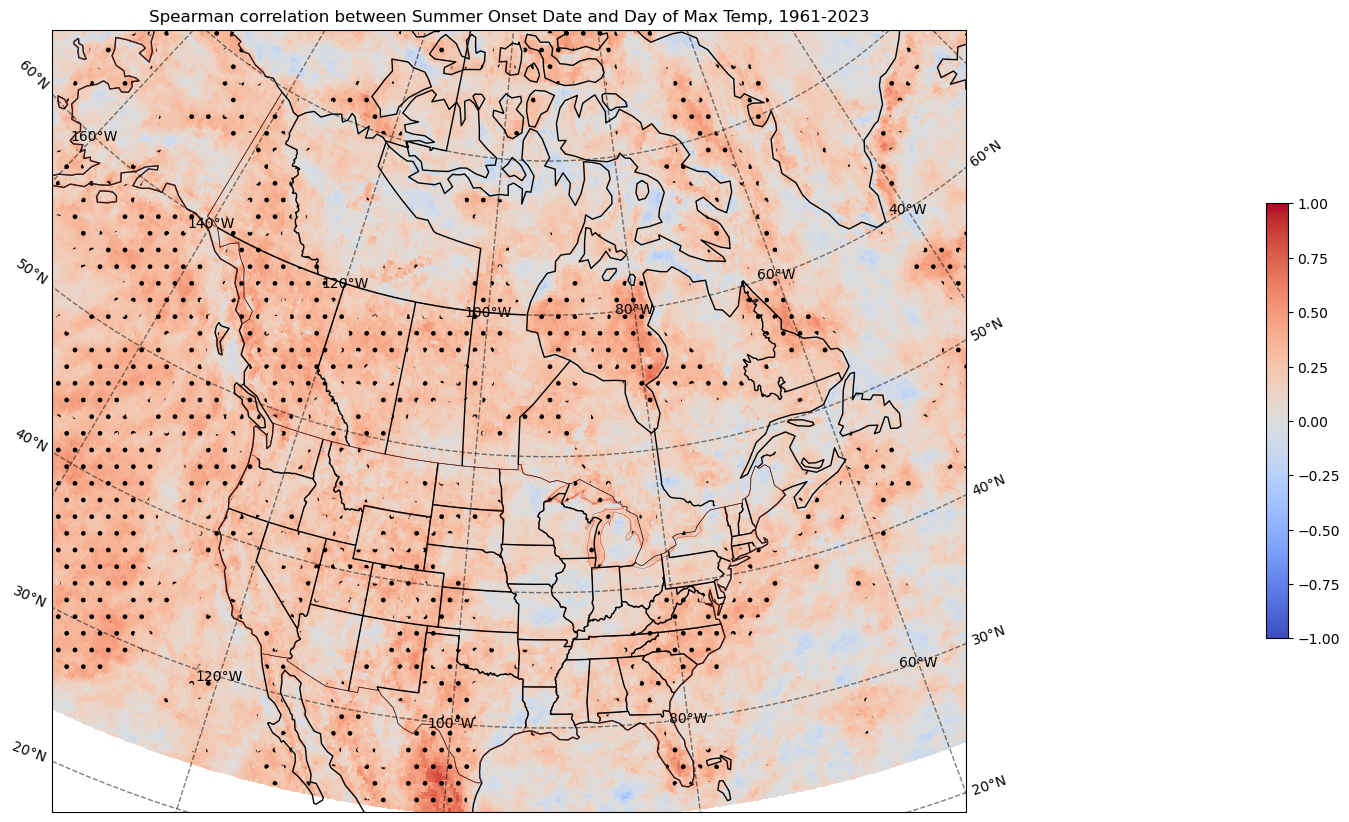

CPU times: user 5.77 s, sys: 160 ms, total: 5.93 s
Wall time: 5.97 s


In [19]:
%%time

central_longitude = -(91 + 52 / 60)
central_latitude = 40

fig = plt.figure(figsize=(15,9))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

# spearman correlation
s_corr.where((s_corr.lat >= 23.5) | (s_corr.lat <= -23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-1,
    vmax=1, 
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)

# mask for sig at p < 0.05 
mksig = s_corr_p.where((s_corr.lat >= 23.5) | (s_corr.lat <= -23.5)) < 0.05

mksig.where(mksig.values).plot.contourf(hatches=".", transform=ccrs.PlateCarree(), 
                                        #colors='none', 
                                        cmap='none' )#cbar_kwargs={'shrink': 0.0})

# remove the colorbar from the contour
fig.axes[-1].remove()

# limit to North Amer
ax.set_extent((-130, -60, 20, 75))
provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)

plt.title("Spearman correlation between Summer Onset Date and Day of Max Temp, 1961-2023")
plt.tight_layout()
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()